# Titanic Dataset: Exploratory Data Analysis & Preprocessing
**Dataset:** [Titanic.csv – Data Science Dojo](https://github.com/datasciencedojo/datasets/blob/master/titanic.csv)

**Objective:** 

1. Loading and understanding the data
2. Exploratory Data Analysis (EDA)
3. Handling missing values
4. Handling outliers
5. Feature engineering
6. Encoding categorical variables
7. Feature scaling
8. Train-test split (preparing data for modeling)

## 1. Setup: Importing Libraries

We use the standard Python data science stack:
- `pandas` – data manipulation
- `numpy` – numerical operations
- `matplotlib` – visualization
- `sklearn` – preprocessing utilities


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Libraries imported successfully")

Libraries imported successfully


In [12]:
# Display settings
pd.set_option('display.max_columns',None )
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Loading the Dataset

In [13]:
df = pd.read_csv('titanic.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Column Descriptions

| Column | Description |
|---|---|
| PassengerId | Unique ID for each passenger |
| Survived | Target variable (0 = No, 1 = Yes) |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | # of siblings/spouses aboard |
| Parch | # of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of Embarkation (C, Q, S) |


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the **structure**, **quality**, and **patterns** in the data before we touch it.

### 3.1 Basic Information

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### 3.2 Checking for Missing Values

This is one of the most important steps — real-world data is almost never complete.

In [15]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df


,Missing Count,Missing %
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


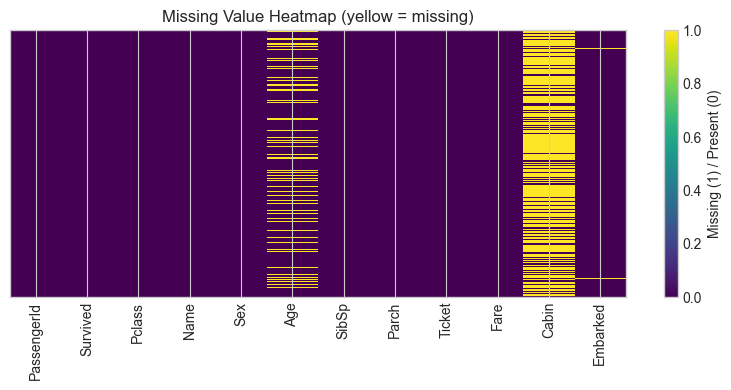

In [16]:
plt.figure(figsize=(8, 4))
plt.imshow(df.isnull(), aspect='auto', cmap='viridis', interpolation='none')
plt.title('Missing Value Heatmap (yellow = missing)')
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks([])
plt.colorbar(label='Missing (1) / Present (0)')
plt.tight_layout()
plt.show()


**Observation:**
- `Cabin` is missing for the majority of passengers — too many to reasonably impute, so we'll engineer a feature from it instead of filling it.
- `Age` has a moderate amount of missing data — a good candidate for imputation.
- `Embarked` has only 1-2 missing values — safe to fill with the mode.


### 3.3 Target Variable Distribution

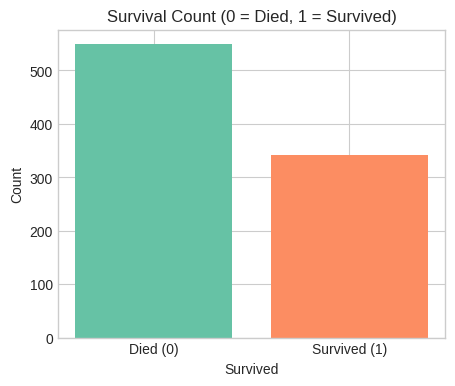

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(5, 4))
counts = df['Survived'].value_counts().sort_index()
plt.bar(['Died (0)', 'Survived (1)'], counts.values, color=['#66c2a5', '#fc8d62'])
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

print(df['Survived'].value_counts(normalize=True) * 100)


In [17]:
   pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


### 3.4 Categorical Feature Analysis

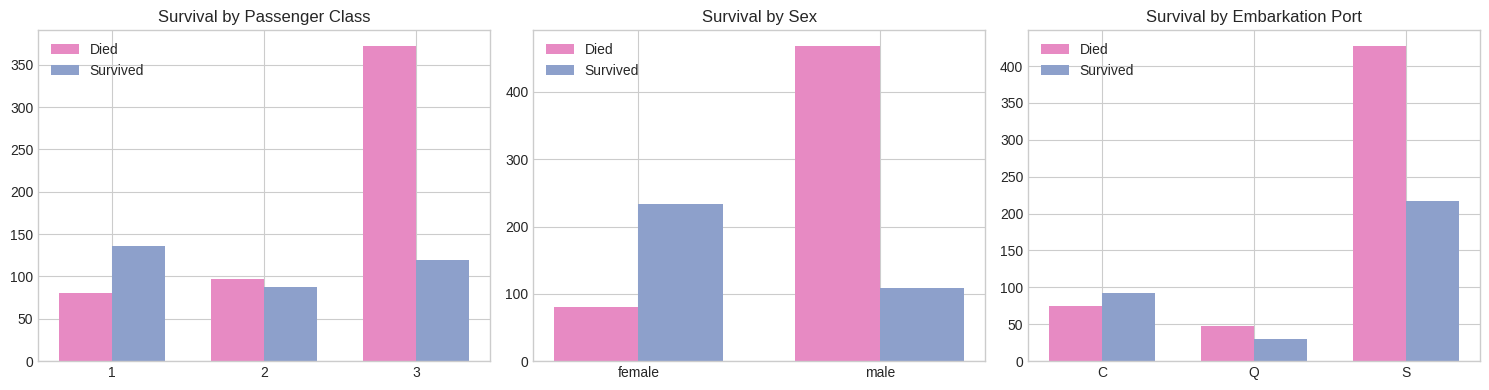

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def grouped_survival_bar(ax, column, title):
    ct = pd.crosstab(df[column], df['Survived'])
    x = np.arange(len(ct.index))
    width = 0.35
    ax.bar(x - width/2, ct[0], width, label='Died', color='#e78ac3')
    ax.bar(x + width/2, ct[1], width, label='Survived', color='#8da0cb')
    ax.set_xticks(x)
    ax.set_xticklabels(ct.index.astype(str))
    ax.set_title(title)
    ax.legend()

grouped_survival_bar(axes[0], 'Pclass', 'Survival by Passenger Class')
grouped_survival_bar(axes[1], 'Sex', 'Survival by Sex')
grouped_survival_bar(axes[2], 'Embarked', 'Survival by Embarkation Port')

plt.tight_layout()
plt.show()


**Insights:**
- Passengers in 1st class had a noticeably higher survival rate than 3rd class.
- Females survived at a much higher rate than males ("women and children first").
- Passengers who embarked from Cherbourg (C) had a relatively higher survival rate.


### 3.5 Numerical Feature Analysis

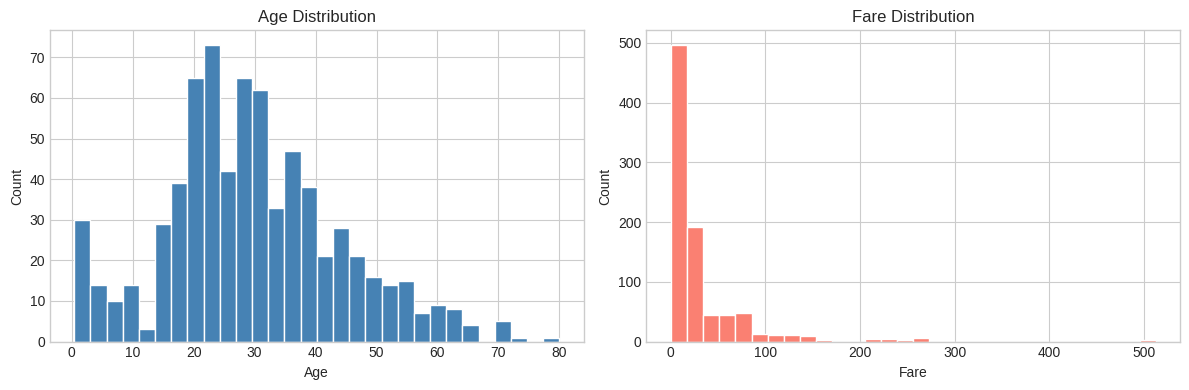

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(df['Fare'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.6 Outlier Detection (Boxplots)

Boxplots make it easy to spot extreme values that could distort a model.

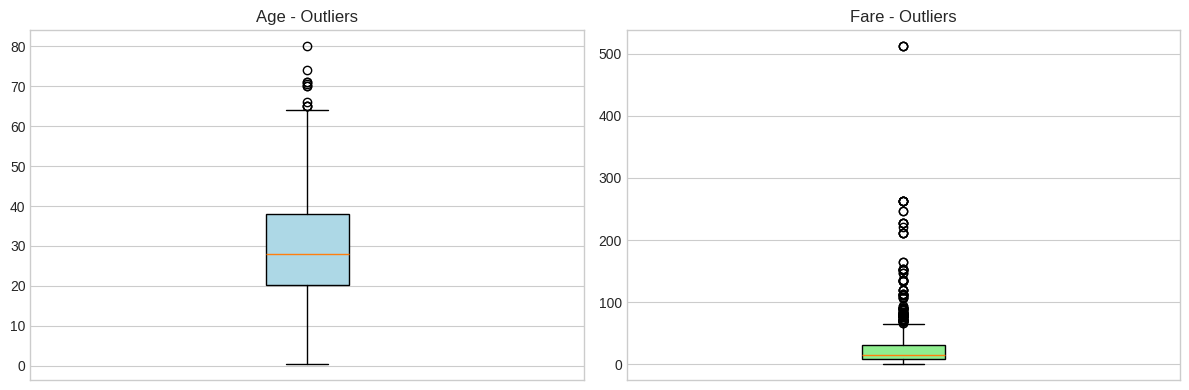

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Age'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Age - Outliers')
axes[0].set_xticks([])

axes[1].boxplot(df['Fare'], patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Fare - Outliers')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

**Observation:** `Fare` has several extreme outliers (some passengers paid very high fares). We'll cap these later using the IQR method instead of deleting rows, so we don't lose data.


### 3.7 Correlation Heatmap

Correlation shows how numeric features move together (only makes sense for numeric columns).

In [19]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [20]:
corr = numeric_df.corr()
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


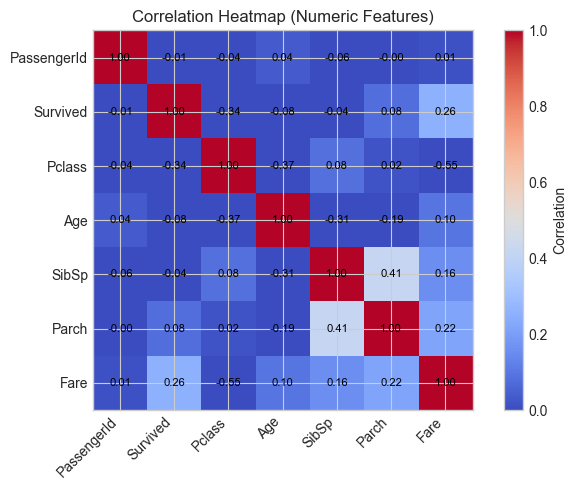

In [23]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
im = plt.imshow(corr, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(im, label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

# Annotate each cell with the correlation value
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                  color='black', fontsize=8)

plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

Now that we understand the data, we clean and transform it so it's ready for machine learning. We'll work on a **copy** of the original dataframe so the raw data stays untouched for reference.


In [12]:
data = df.copy()
data.shape


(891, 12)

### 4.1 Dropping Irrelevant Columns

`PassengerId`, `Ticket` are just identifiers with no predictive value. `Name` will be used once (to extract Title) and then dropped.

In [13]:
# Keep Name for now to extract Title, drop it after
data.drop(columns=['PassengerId', 'Ticket'], inplace=True)
data.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


### 4.2 Handling Missing Values

**Strategy:**
- `Age` → fill with the **median** (robust to outliers, unlike the mean)
- `Embarked` → fill with the **mode** (most common port)
- `Cabin` → too sparse to impute; convert into a binary feature `HasCabin` instead


In [14]:
# Age: fill with median
data['Age'] = data['Age'].fillna(data['Age'].median())

# Embarked: fill with mode
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Cabin: convert to a binary "HasCabin" feature, then drop original column
data['HasCabin'] = data['Cabin'].notnull().astype(int)
data.drop(columns=['Cabin'], inplace=True)

# Verify no missing values remain (except Name, which we still need briefly)
data.isnull().sum()


Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

### 4.3 Feature Engineering

Raw columns aren't always the most useful — we can create new, more informative features:

- **Title**: extracted from `Name` (Mr, Mrs, Miss, Master, etc.) — often a strong predictor of age/social status
- **FamilySize**: `SibSp + Parch + 1` (the passenger themself)
- **IsAlone**: whether the passenger was traveling alone


In [15]:
# Extract Title from Name
data['Title'] = data['Name'].str.extract(r',\s*([^\.]*)\s*\.')

# Group rare titles together
title_counts = data['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
data['Title'] = data['Title'].replace(rare_titles, 'Rare')
data['Title'] = data['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print(data['Title'].value_counts())

# Now we can drop Name
data.drop(columns=['Name'], inplace=True)


Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [16]:
# Family size and IsAlone
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

data[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()


,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


### 4.4 Handling Outliers in `Fare`

We'll cap (clip) extreme values using the **IQR method** instead of deleting rows — this keeps all passengers in the dataset while reducing the influence of extreme fares.

Lower bound: -26.72, Upper bound: 65.63


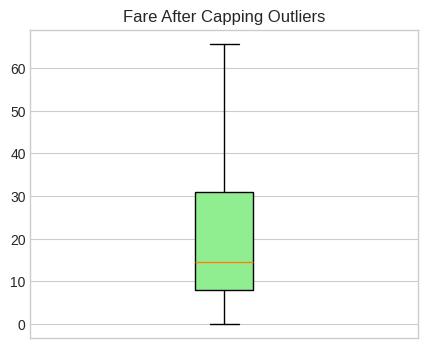

In [17]:
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

data['Fare'] = data['Fare'].clip(lower=lower_bound, upper=upper_bound)

plt.figure(figsize=(5, 4))
plt.boxplot(data['Fare'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Fare After Capping Outliers')
plt.xticks([])
plt.show()


### 4.5 Encoding Categorical Variables

Machine learning models need numbers, not text. We use two common approaches:

- **Label Encoding**: for binary categories like `Sex` (male/female → 0/1)
- **One-Hot Encoding**: for categories with no natural order, like `Embarked` and `Title`


In [18]:
# Label encode Sex (binary category)
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked and Title (nominal categories)
data = pd.get_dummies(data, columns=['Embarked', 'Title'], drop_first=True)

data.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,0,2,0,False,True,False,True,False,False
1,1,1,1,38.0,1,0,65.6344,1,2,0,False,False,False,False,True,False
2,1,3,1,26.0,0,0,7.9250,0,1,1,False,True,True,False,False,False
3,1,1,1,35.0,1,0,53.1000,1,2,0,False,True,False,False,True,False
4,0,3,0,35.0,0,0,8.0500,0,1,1,False,True,False,True,False,False


### 4.6 Feature Scaling

Some algorithms (e.g. KNN, SVM, Logistic Regression, Neural Networks) are sensitive to the scale of features. We standardize `Age` and `Fare` so they have mean 0 and standard deviation 1.

> Tree-based models (Decision Tree, Random Forest, XGBoost) don't require scaling, but it's still good practice to know how to do it.


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])

data[['Age', 'Fare']].describe()


,Age,Fare
count,8.910000e+02,8.910000e+02
mean,2.272780e-16,9.968332e-17
std,1.000562e+00,1.000562e+00
min,-2.224156e+00,-1.174727e+00
25%,-5.657365e-01,-7.882908e-01
50%,-1.046374e-01,-4.686152e-01
75%,4.333115e-01,3.396748e-01
max,3.891554e+00,2.031623e+00


### 4.7 Final Preprocessed Dataset

In [20]:
print("Final shape:", data.shape)
data.head()


Final shape: (891, 16)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,-0.565736,1,0,-0.820552,0,2,0,False,True,False,True,False,False
1,1,1,1,0.663861,1,0,2.031623,1,2,0,False,False,False,False,True,False
2,1,3,1,-0.258337,0,0,-0.787578,0,1,1,False,True,True,False,False,False
3,1,1,1,0.433312,1,0,1.419297,1,2,0,False,True,False,False,True,False
4,0,3,0,0.433312,0,0,-0.781471,0,1,1,False,True,False,True,False,False


## 5. Train-Test Split

The last step before modeling: separate features (`X`) from the target (`y`), then split into training and testing sets so we can evaluate a model fairly on unseen data.


In [21]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))


X_train: (712, 15)
X_test: (179, 15)
y_train distribution:
 Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
